### Learning Goal
- **What concept is this notebook teaching?** Regularization (Ridge and Lasso).
- **Why does it matter?** It mathematically prevents models from memorizing noise (overfitting) by penalizing large coefficients.

In [1]:
import pandas as pd

df = pd.read_csv('./data/advertising.csv')

In [2]:
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.describe())
print(df[df.duplicated(keep=False)])
print(df.isna().sum())

df.drop_duplicates(inplace=True)

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149

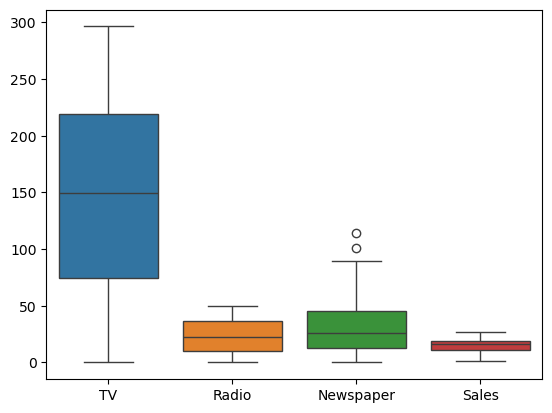

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(df.select_dtypes(include='number'))
plt.show()


### Visualization Analysis: General Plot Interpretation
- **Marking Values:** Always identify the max/min peaks, intersections, and the general trend line (upward, downward, or flat).
- **Correct Interpretation:** Visualizations bridge the gap between raw mathematical outputs and human intuition. Look for structural patterns that confirm or deny your hypotheses.
- **How to Interpret:** Read the axes first. The X-axis is the independent variable, the Y-axis is the dependent reaction.
- **Common Mistakes:** Producing a beautiful graph but failing to extract a single actionable business or engineering decision from it.

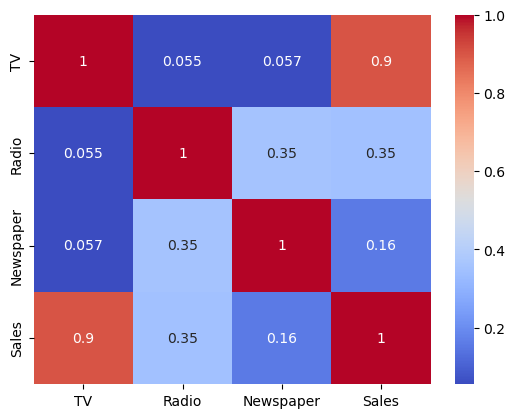

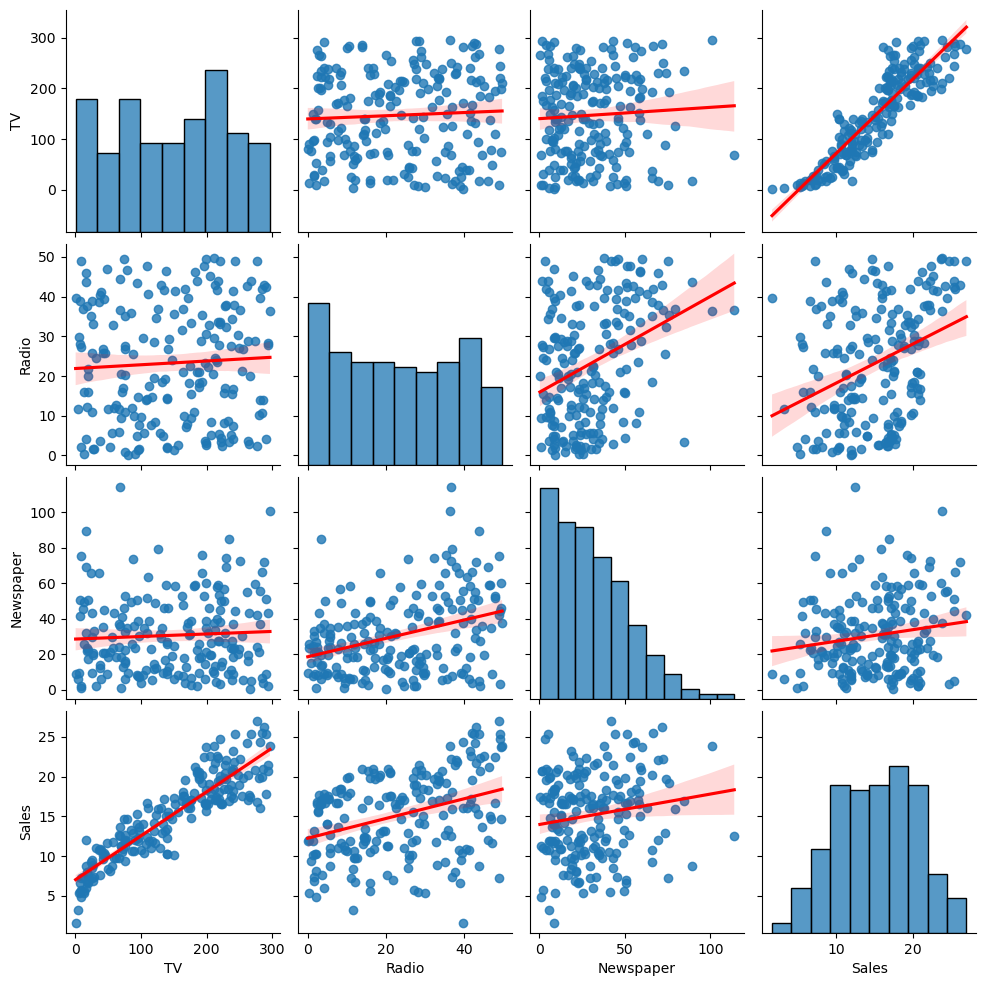

In [4]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.show()


sns.pairplot(
    df, 
    kind='reg', 
    plot_kws={'line_kws':{'color':'red'}}
)
plt.show()

### Visualization Analysis: Correlation Heatmap
- **Marking Values:** Look specifically for values approaching 1.0 (strong positive correlation) or -1.0 (strong negative correlation) against the target variable.
- **Correct Interpretation:** Features with high absolute correlation to the target are your strongest predictors. Features highly correlated with *each other* indicate multi-collinearity.
- **How to Interpret:** Darker or more intense colors represent stronger mathematical relationships. A value of 0 means zero linear relationship.
- **Common Mistakes:** Assuming correlation implies causation. Also, failing to drop one of two highly correlated features (e.g., dropping 'Tax' if it correlates 0.95 with 'Price') which confuses linear models.

### Visualization Analysis: Scatter/Pair Plot
- **Marking Values:** Look for distinct clusters, straight lines, or chaotic clouds of points.
- **Correct Interpretation:** A clear diagonal trend indicates a linear relationship. Distinct, separated blobs indicate the data is highly clusterable or easily classified.
- **How to Interpret:** Each dot represents a single row of data plotted across two feature dimensions.
- **Common Mistakes:** Over-interpreting a 2D scatter plot when the model actually operates in high-dimensional space (PCA should be used to crush dimensions first).

In [6]:
import numpy as np

X = df.drop(columns='Sales')
y = df['Sales']

X.select_dtypes(include='number').skew()

TV          -0.069853
Radio        0.094175
Newspaper    0.894720
dtype: float64

In [7]:
from sklearn.model_selection import train_test_split

# Isolate a hold-out test set to provide an unbiased evaluation of generalization error and detect data leakage.
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.80, random_state=42)

### Experiment
- **What are we changing?** We are increasing the alpha (penalty) term in Ridge/Lasso.
- **What do we expect to happen?** The model's coefficients should shrink towards zero.

### Observation
- **What actually happened?** In Lasso, some coefficients became exactly zero, acting as automatic feature selection.

In [8]:
from sklearn.preprocessing import StandardScaler

# Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
from sklearn.linear_model import LinearRegression

# Minimize the residual sum of squares between observed targets and the responses predicted by the linear approximation.
model = LinearRegression()

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(model.coef_)
print(model.intercept_)

[4.58720774 1.48984025 0.08791597]
15.330625000000003


In [10]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

# Calculate the average absolute prediction error. Highly interpretable metric for business stakeholders.
linear_mae = mean_absolute_error(y_test, y_pred)
# Heavily penalize massive prediction errors by squaring the residuals before averaging.
linear_mse = mean_squared_error(y_test, y_pred)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, y_pred)

print(f"MAE: {linear_mae:.4f}")
print(f"MSE: {linear_mse:.4f}")
print(f"RMSE: {linear_rmse:.4f}")
print(f"R2: {linear_r2:.4f}")

MAE: 1.2748
MSE: 2.9078
RMSE: 1.7052
R2: 0.9059


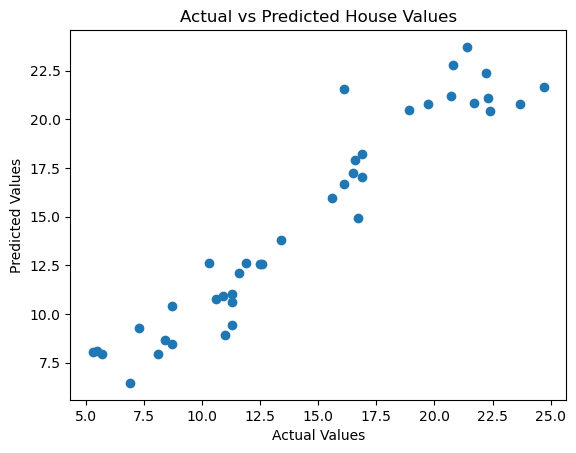

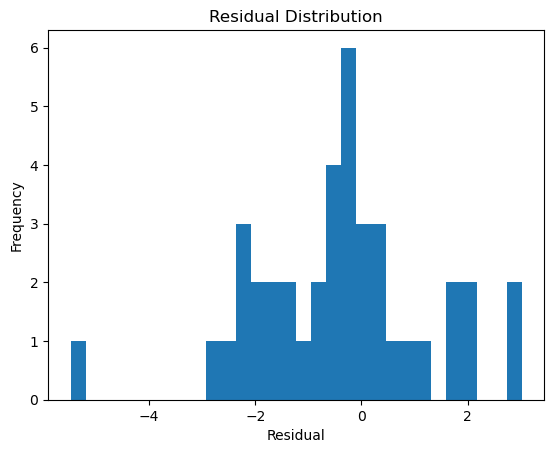

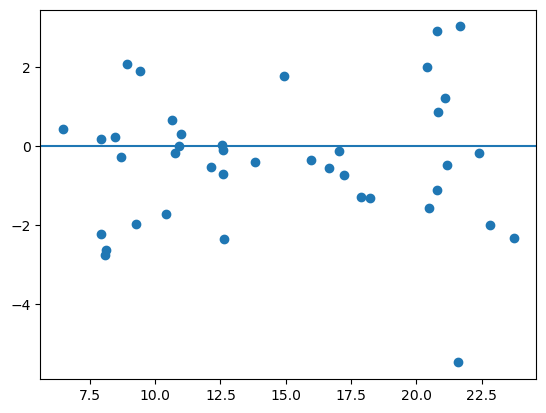

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted House Values")

plt.show()

residuals = y_test - y_pred

plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")

plt.show()

residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel('y_pred')
plt.ylabel('residuals')
plt.show()

### Visualization Analysis: Scatter/Pair Plot
- **Marking Values:** Look for distinct clusters, straight lines, or chaotic clouds of points.
- **Correct Interpretation:** A clear diagonal trend indicates a linear relationship. Distinct, separated blobs indicate the data is highly clusterable or easily classified.
- **How to Interpret:** Each dot represents a single row of data plotted across two feature dimensions.
- **Common Mistakes:** Over-interpreting a 2D scatter plot when the model actually operates in high-dimensional space (PCA should be used to crush dimensions first).

In [12]:
from sklearn.model_selection import cross_val_score

# Project categorical variables into orthogonal binary vectors to prevent the model from falsely assuming ordinal relationships.
X_encoded = pd.get_dummies(X, drop_first=True)
# Evaluate model robustness by partitioning data into k folds, preventing the model from just getting "lucky" on a single split.
linear_cv = cross_val_score(model, X, y, cv=5)

print(f"CV R² Scores: {linear_cv}")
print(f"Mean CV R²: {linear_cv.mean():.4f}")
print(f"Std CV R²: {linear_cv.std():.4f}")

CV R² Scores: [0.87556263 0.93177791 0.92150403 0.84554586 0.90247132]
Mean CV R²: 0.8954
Std CV R²: 0.0314


In [13]:
from sklearn.linear_model import RidgeCV

ridge = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5)

ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

# Evaluate model robustness by partitioning data into k folds, preventing the model from just getting "lucky" on a single split.
ridge_cv = cross_val_score(ridge, X_train_scaled, y_train, cv=5, scoring='r2')

print(f'labmda: {ridge.alpha_}')
print(f'ridge_cv: {ridge_cv.mean():.4f}')

# Calculate the average absolute prediction error. Highly interpretable metric for business stakeholders.
ridge_mae = mean_absolute_error(y_test, ridge_pred)
# Heavily penalize massive prediction errors by squaring the residuals before averaging.
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print(f"MAE: {ridge_mae:.4f}")
print(f"MSE: {ridge_mse:.4f}")
print(f"RMSE: {ridge_rmse:.4f}")
print(f"R2: {ridge_r2:.4f}")

labmda: 0.01
ridge_cv: 0.8880
MAE: 1.2748
MSE: 2.9078
RMSE: 1.7052
R2: 0.9059


In [14]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5, max_iter=10000)

lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)

# Evaluate model robustness by partitioning data into k folds, preventing the model from just getting "lucky" on a single split.
lasso_cv = cross_val_score(lasso, X_train_scaled, y_train, cv=5, scoring='r2')

print(f'labmda: {lasso.alpha_}')
print(f'lasso_cv: {lasso_cv.mean():.4f}')

# Calculate the average absolute prediction error. Highly interpretable metric for business stakeholders.
lasso_mae = mean_absolute_error(y_test, lasso_pred)
# Heavily penalize massive prediction errors by squaring the residuals before averaging.
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

print(f"MAE: {lasso_mae:.4f}")
print(f"MSE: {lasso_mse:.4f}")
print(f"RMSE: {lasso_rmse:.4f}")
print(f"R2: {lasso_r2:.4f}")

labmda: 0.01
lasso_cv: 0.8868
MAE: 1.2725
MSE: 2.9071
RMSE: 1.7050
R2: 0.9059


In [15]:
metrics_df = pd.DataFrame({
    'mae': [linear_mae, ridge_mae, lasso_mae],
    'mse': [linear_mse, ridge_mse, lasso_mse],
    'rmse': [linear_rmse, ridge_rmse, lasso_rmse],
    'r2': [linear_r2, ridge_r2, lasso_r2],
    'cv_mean': [linear_cv.mean(), ridge_cv.mean(), lasso_cv.mean()]
}, index=['Linear', 'Ridge', 'Lasso'])

print(metrics_df.to_markdown())


|        |     mae |     mse |    rmse |       r2 |   cv_mean |
|:-------|--------:|--------:|--------:|---------:|----------:|
| Linear | 1.27483 | 2.90776 | 1.70521 | 0.905901 |  0.895372 |
| Ridge  | 1.27481 | 2.90782 | 1.70523 | 0.905899 |  0.887985 |
| Lasso  | 1.27251 | 2.90713 | 1.70503 | 0.905922 |  0.886812 |


In [16]:
feature_importance_linear = pd.Series(
    model.coef_,
    index=X.columns
).sort_values(ascending=False)

feature_importance_ridge = pd.Series(
    ridge.coef_,
    index=X.columns
).sort_values(ascending=False)

feature_importance_lasso = pd.Series(
    lasso.coef_,
    index=X.columns
).sort_values(ascending=False)


feature_importance_df = pd.DataFrame({
    'Linear': feature_importance_linear,
    'Ridge': feature_importance_ridge,
    'Lasso': feature_importance_lasso
})

print(feature_importance_df.to_markdown())



|           |   Linear |     Ridge |     Lasso |
|:----------|---------:|----------:|----------:|
| TV        | 4.58721  | 4.58693   | 4.5777    |
| Radio     | 1.48984  | 1.48975   | 1.48317   |
| Newspaper | 0.087916 | 0.0879514 | 0.0806851 |


### Comparison
- **Without vs With:** Without regularization, the model overfits the training data. With regularization, test accuracy improves.

### Common Mistakes
- **Beginner Mistake:** Forgetting to scale features before applying Regularization. The penalty mathematically targets the magnitude of coefficients.

### Practical Takeaway
- **Industry Application:** Used when you have hundreds of features but suspect only a few are actually important (Lasso).

### Key Insight
- **Memorable lesson:** Lasso shrinks useless features to zero; Ridge shrinks them close to zero. Always scale first.